In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from netCDF4 import Dataset

import iris
import iris.coord_categorisation
import iris.plot as iplt
import iris.quickplot as qplt

import os
import logging

import numpy as np
import numpy.ma as ma

import pickle
from pathlib import Path

from IPython.display import clear_output
import gc

logger = logging.getLogger(__name__)



Purpose: Read in pre-existing pickle files of global and regional mean carbon
        pools for all models and all landuse scenarios. Generate plots of
        c_veg, c_soil, c_harvest, c_products, and c_tot for all models.

        The plot should have one thick line showing the mean across the 3 climate 
        model forcings for each of the models and SSP scenarios.


In [2]:
run plot_tools.ipynb

In [3]:
def average_dict(input):
    output=sum( np.array(input[clim] )[0][:] for clim in ESMS) / 3
    return(output)

In [4]:
def sum_carbon_pools(input):
    output=sum( np.array(input[var] ) [0][:] for var in VARIABLES )
    return(output)

jules
cVeg jules ssp126 slope over 2090s: -0.21592207664598045
cVeg jules ssp370 slope over 2090s: 1.8759970871384377
clm
cVeg clm ssp126 slope over 2090s: 0.2769490215727639
cVeg clm ssp370 slope over 2090s: 4.127188756703609
jsbach
cVeg jsbach ssp126 slope over 2090s: 0.33321245771056157
cVeg jsbach ssp370 slope over 2090s: 2.768626953236922
orchidee
cVeg orchidee ssp126 slope over 2090s: -0.005400779096679284
cVeg orchidee ssp370 slope over 2090s: 1.4083415239922048
jules
cSoil jules ssp126 slope over 2090s: 0.1007993031772793
cSoil jules ssp370 slope over 2090s: -0.3878210273162538
clm
cSoil clm ssp126 slope over 2090s: 0.2218464487756988
cSoil clm ssp370 slope over 2090s: -0.1293608230356505
jsbach
cSoil jsbach ssp126 slope over 2090s: 0.1044056845275716
cSoil jsbach ssp370 slope over 2090s: 0.42607459301174333
orchidee
cSoil orchidee ssp126 slope over 2090s: 0.12204946382412013
cSoil orchidee ssp370 slope over 2090s: 0.11777195707613515
clm
cProduct clm ssp126 slope over 2090s: -

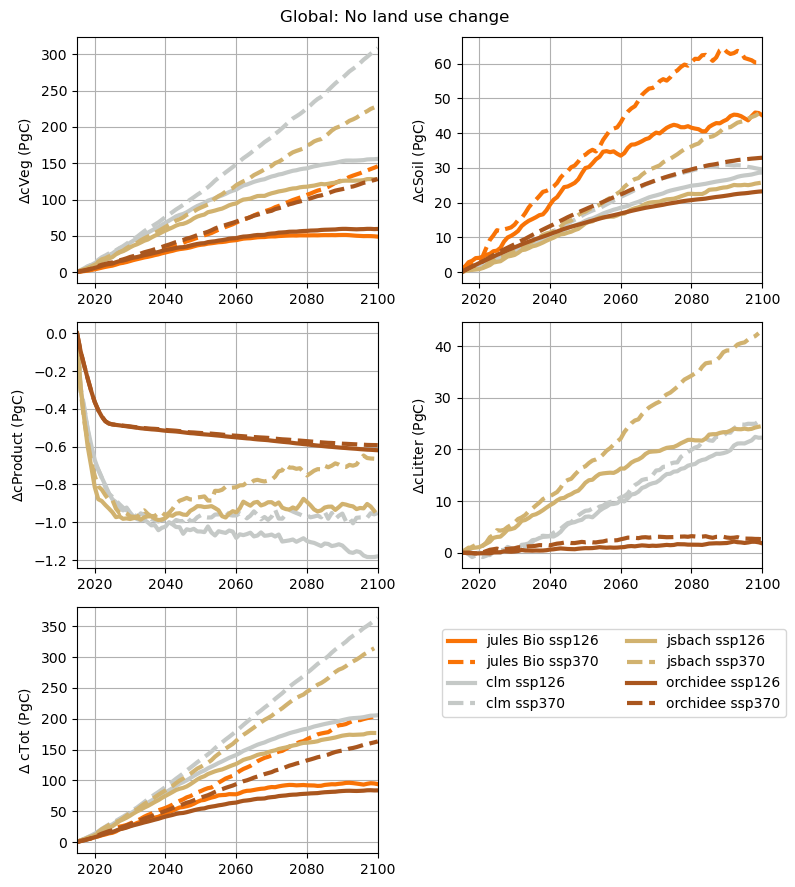

In [5]:
REGIONS=['Global','Tropics','NH-Temperate']
DECADES=['start','2030s','2050s','2090s']
MODELS=['jules','clm','jsbach','orchidee']
LANDUSES=['nolucaff','noluc','agtobio', 'agtonat', 'agtoaff', 'nattobio', 'nattoaff']
#SSPS=['ssp126']
SSPS=['ssp126','ssp370']
ESMS=['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']
VARIABLES=['cVeg','cSoil','cProduct','cLitter','cTot']

plot_all=False
plot_aff=False
region='Global'

years = np.arange(2015,2101)     
nyears = len(years)

#Set up plotting stuff
#Each land model needs a different color
fig,axes=plt.subplots(3,2, figsize=[8,9])
fig.suptitle(region+': No land use change',fontsize=12)
ix=0
iy=0

LU_SCENARIO_MEAN = {var: {lsm_mod: {region: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
                    for landuse in LANDUSES} for region in REGIONS} for lsm_mod in MODELS} 
                    for var in VARIABLES}
LU_SCENARIO_ALL = {var: {lsm_mod: {region: {landuse: {esm: {ssp_scen: [] for ssp_scen in SSPS} 
                    for esm in ESMS} for landuse in LANDUSES} for region in REGIONS} 
                    for lsm_mod in MODELS} for var in VARIABLES}
BOXPLOT_INPUT = {decade: {landuse: {ssp_scen: {vals: [] for vals in range(12)} for ssp_scen in SSPS} 
                for landuse in LANDUSES} for decade in DECADES} 
CTOT = {landuse: {lsm: {ssp: {esm: [] for esm in ESMS} for ssp in SSPS} 
                  for lsm in MODELS} for landuse in LANDUSES}
landuse_exists = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
landuse_exists['jsbach']['agtonat'] = False
landuse_exists['jsbach']['nattoaff'] = False
landuse_exists['orchidee']['agtobio'] = False
landuse_exists['orchidee']['agtonat'] = False
landuse_exists['orchidee']['nattobio'] = False

variable_exists = {var: {lsm_mod: [True] for lsm_mod in MODELS} for var in VARIABLES}
variable_exists['cProduct']['jules'] = False
variable_exists['cLitter']['jules'] = False


test_mean={ssp: [] for ssp in SSPS}
colors = {model: [] for model in MODELS}
colors['jules'] = '#F97306'
colors['clm'] = '#C5C9C7'
colors['jsbach'] = '#D1B26F'
colors['orchidee'] = '#A9561E'
#https://matplotlib.org/stable/users/explain/colors/colors.html

linestyles = {ssp: [] for ssp in SSPS}
linestyles['ssp126'] = '-'
linestyles['ssp370'] = '--'

#cVeg and cSoil are easy
for var in VARIABLES[:-1]:

    # set axes
    ax=axes[iy,ix]
    ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 
    
    for model in MODELS:
        #First get no land use change (noluc)
        if variable_exists[var][model]:
            print(model)
            if model=='jules':
                nolucbio,nolucbio_tr,nolucbio_te = retrieve_data_generic(var,'PgC','nolucbio',model)
                nolucaff,nolucaff_tr,nolucaff_te = retrieve_data_generic(var,'PgC','nolucaff',model)
                for ssp in SSPS:
                    LU_SCENARIO_MEAN[var][model]['Global']['nolucaff'][ssp]=average_dict(nolucaff[ssp])
                    LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(nolucbio[ssp])
                    LU_SCENARIO_MEAN[var][model]['Tropics']['nolucaff'][ssp]=average_dict(nolucaff_tr[ssp])
                    LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(nolucbio_tr[ssp])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate']['nolucaff'][ssp]=average_dict(nolucaff_te[ssp])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(nolucbio_te[ssp])
                    for esm in ESMS:
                        LU_SCENARIO_ALL[var][model]['Global']['nolucaff'][esm][ssp]=nolucaff[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=nolucbio[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics']['nolucaff'][esm][ssp]=nolucaff_tr[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=nolucbio_tr[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate']['nolucaff'][esm][ssp]=nolucaff_te[ssp][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=nolucbio_te[ssp][esm][0][:]
            else:
                if var=='cLitter' and model=='clm':
                    cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC','noluc',model)
                    cwd,cwd_tr,cwd_te = retrieve_data_generic('cCwd','PgC','noluc',model)
                    #litter is small
                    for ssp in SSPS:
                        LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(cwd[ssp]) + average_dict(cdata[ssp])
                        LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(cwd_tr[ssp]) + average_dict(cdata_tr[ssp])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(cwd_te[ssp]) + average_dict(cdata_te[ssp])
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=cwd[ssp][esm][0][:] + cdata[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=cwd_tr[ssp][esm][0][:] + cdata_tr[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=cwd_te[ssp][esm][0][:] + cdata_te[ssp][esm][0][:]                   
                
                else:
                    noluc,noluc_tr,noluc_te = retrieve_data_generic(var,'PgC','noluc',model)
                    for ssp in SSPS:
                        LU_SCENARIO_MEAN[var][model]['Global']['noluc'][ssp]=average_dict(noluc[ssp]) 
                        LU_SCENARIO_MEAN[var][model]['Tropics']['noluc'][ssp]=average_dict(noluc_tr[ssp]) 
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate']['noluc'][ssp]=average_dict(noluc_te[ssp]) 
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global']['noluc'][esm][ssp]=noluc[ssp][esm][0][:] 
                            LU_SCENARIO_ALL[var][model]['Tropics']['noluc'][esm][ssp]=noluc_tr[ssp][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate']['noluc'][esm][ssp]=noluc_te[ssp][esm][0][:] 
            #Next get land use change scenarios
            for landuse in LANDUSES[2:]:
                if (landuse_exists[model][landuse]):
                    cdata,cdata_tr,cdata_te = retrieve_data_generic(var,'PgC',landuse,model)
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126']=average_dict(cdata['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370']=average_dict(cdata['ssp370'])
                    LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp126']=average_dict(cdata_tr['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp370']=average_dict(cdata_tr['ssp370'])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp126']=average_dict(cdata_te['ssp126'])
                    LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp370']=average_dict(cdata_te['ssp370'])
                    for esm in ESMS:
                        LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp126']=cdata['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp370']=cdata['ssp370'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp126']=cdata_tr['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp370']=cdata_tr['ssp370'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp126']=cdata_te['ssp126'][esm][0][:]
                        LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp370']=cdata_te['ssp370'][esm][0][:]
                    if var=='cLitter' and model=='clm':
                        cwd,cwd_tr,cwd_te = retrieve_data_generic('cCwd','PgC',landuse,model)
                        LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp126']+=average_dict(cwd['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['Global'][landuse]['ssp370']+=average_dict(cwd['ssp370'])
                        LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp126']+=average_dict(cwd_tr['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['Tropics'][landuse]['ssp370']+=average_dict(cwd_tr['ssp370'])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp126']+=average_dict(cwd_te['ssp126'])
                        LU_SCENARIO_MEAN[var][model]['NH-Temperate'][landuse]['ssp370']+=average_dict(cwd_te['ssp370'])
                        for esm in ESMS:
                            LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp126']+=cwd['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Global'][landuse][esm]['ssp370']+=cwd['ssp370'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp126']+=cwd_tr['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['Tropics'][landuse][esm]['ssp370']+=cwd_tr['ssp370'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp126']+=cwd_te['ssp126'][esm][0][:]
                            LU_SCENARIO_ALL[var][model]['NH-Temperate'][landuse][esm]['ssp370']+=cwd_te['ssp370'][esm][0][:]
                                                
                
            # FIRST PLOT THE NO LAND USE CHANGE SCENARIO.
            for ssp in SSPS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                plot_noluc=(LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])- \
                            (LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])[0]
                if model=='jules':
                    plabel=model+' Bio '+ssp
                else:
                    plabel=model+' '+ssp
                ax.plot(years[:endyear], plot_noluc, label=plabel,
                        c=colors[model],ls=linestyles[ssp],lw=3)                  
                if plot_all:
                    for esm in ESMS:
                        plot_clim=(LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])- \
                                      (LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])[0]
                        ax.plot(years[:endyear], plot_clim, c=colors[model], ls=linestyles[ssp], lw=1)
                #print(var,model,ssp,plot_noluc[-1])

                m,b = np.polyfit(years[endyear-11:endyear-1],plot_noluc[-11:-1], 1)
                print(var,model,ssp,'slope over 2090s:',m)

                if model=='jules':
                    if plot_aff:
                        plot_noluc=(LU_SCENARIO_MEAN[var][model][region]['nolucaff'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['nolucaff'][ssp])[0]
                        ax.plot(years[:endyear], plot_noluc, label=model+' Aff '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=1)  
                        #print(var,model,'nolucaff',ssp,plot_noluc[-1])
                    m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                    #print(var,model,'nolucaff',ssp,'slope over last 20 years:',m)
    
    ix+=1
    if ix==2:
        ix=0
        iy+=1


#Plot the sum
ax=axes[iy,ix]
ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
ax.set_xlim([2015,2100])
ax.grid(True) 
for model in MODELS:
    for ssp in SSPS:
        if model=='jsbach':
            endyear=nyears-1
        else:
            endyear=nyears
        ctot_noluc=0
        for var in VARIABLES[:-1]:
            if variable_exists[var][model]:                
                ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region]['noluc'][ssp])
        if model=='jules':
            plabel=model+' Bio '+ssp
        else:
            plabel=model+' '+ssp        
        ax.plot(years[:endyear], (ctot_noluc-ctot_noluc[0]), label=plabel,
                c=colors[model],ls=linestyles[ssp],lw=3)
        #print('cTot:',model,ssp,(ctot_noluc-ctot_noluc[0])[-1])
        m,b = np.polyfit(years[endyear-11:endyear-1],(ctot_noluc[-11:-1]-ctot_noluc[0]), 1)
        print('cTot:',model,ssp,'slope over 2090s:',m)        
        del(ctot_noluc)

        # Save CTOT for the summary plot, which needs each ESM
        # For now, I just want JULES NOLUCBIO
        for esm in ESMS:
            ctot=0
            for var in VARIABLES[:-1]:
                if variable_exists[var][model]:
                    ctot += np.array(LU_SCENARIO_ALL[var][model][region]['noluc'][esm][ssp])
            print("IS THIS OKAY????",ctot)
            CTOT['noluc'][model][ssp][esm]=ctot
            del(ctot)
        
        if model=='jules':
            if plot_aff:
                ctot_noluc=0
                for var in VARIABLES[:-1]:
                    if variable_exists[var][model]:                
                        ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region]['nolucaff'][ssp])
                
                ax.plot(years[:endyear], (ctot_noluc-ctot_noluc[0]), label=model+' Aff '+ssp,
                        c=colors[model],ls=linestyles[ssp],lw=1)
                #print('cTot:',model,'nolucaff',ssp,(ctot_noluc-ctot_noluc[0])[-1])
                m,b = np.polyfit(years[endyear-20:endyear-1],(ctot_noluc[-20:-1]-ctot_noluc[0]), 1)
                #print(var,model,'nolucaff',ssp,'slope over last 20 years:',m)        
                del(ctot_noluc)

handles,labels = ax.get_legend_handles_labels()
ax=axes[2,1]
ax.remove()
fig.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.55, 0.3),fontsize=10)
fig.tight_layout()

if plot_all:
    plt.savefig('/bdd/ESM2025/WP10/plots/cpools_noluc_ALL_'+region+'.png', format="png")
else:
    plt.savefig('/bdd/ESM2025/WP10/plots/cpools_noluc_'+region+'.png', format="png")
    

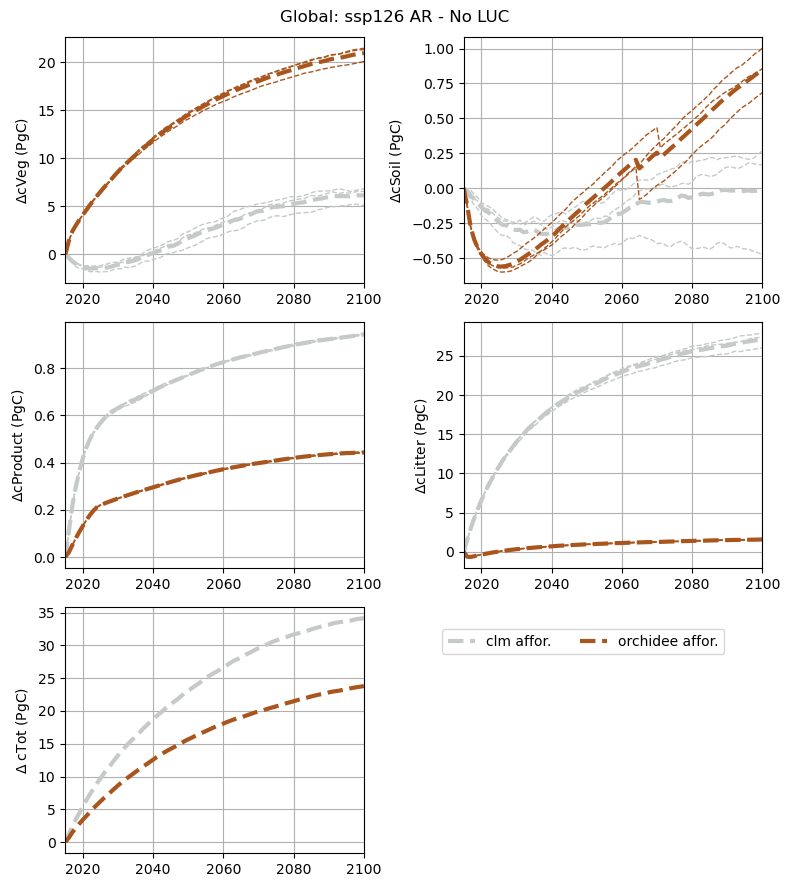

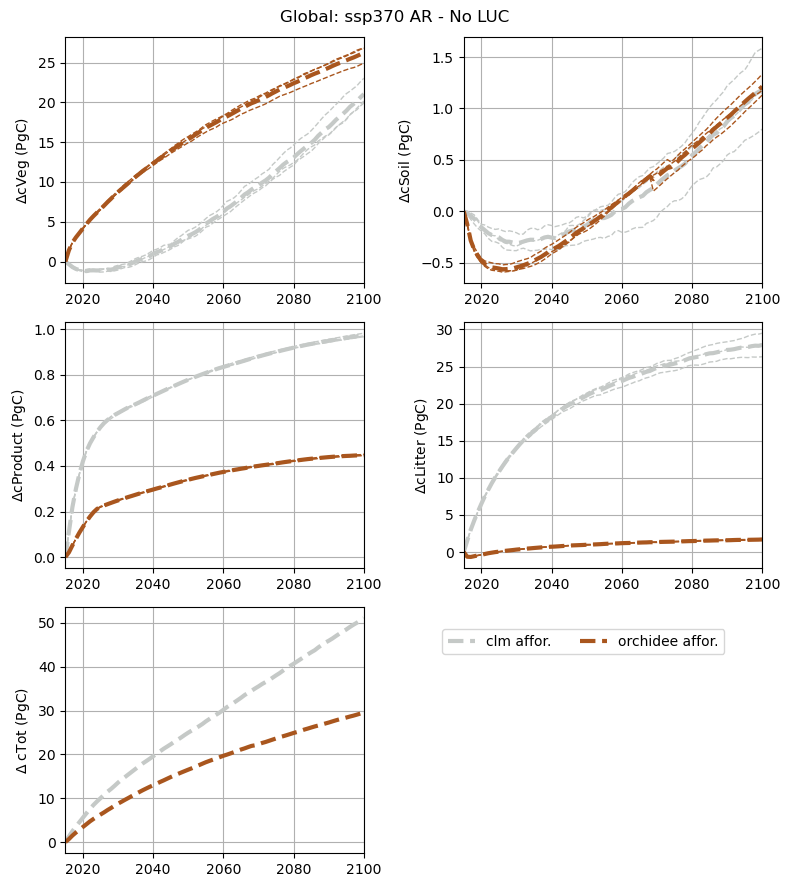

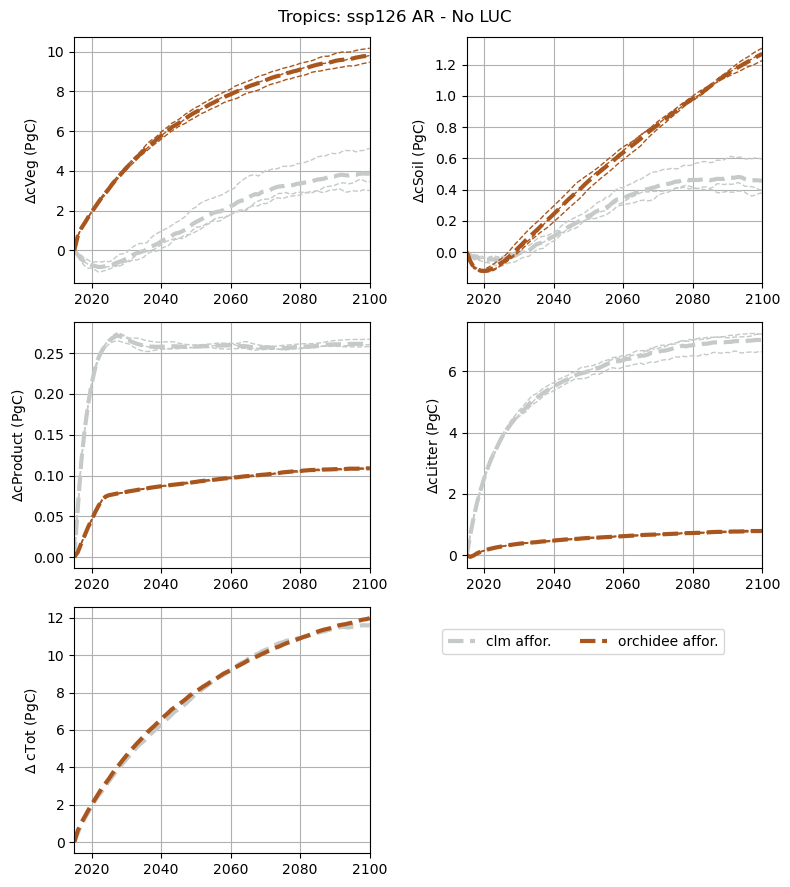

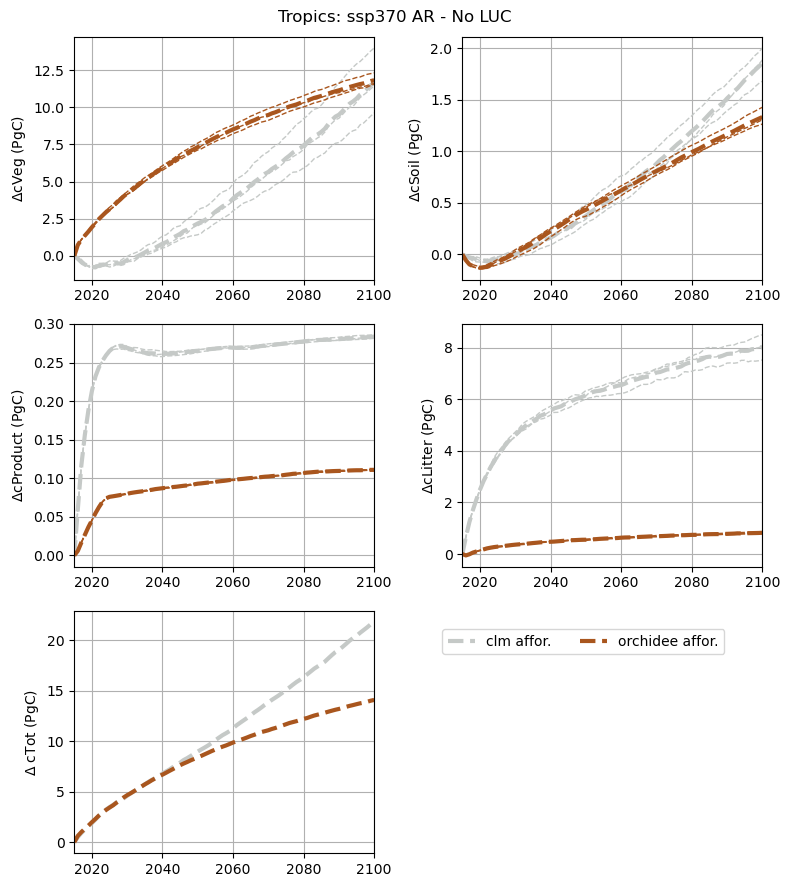

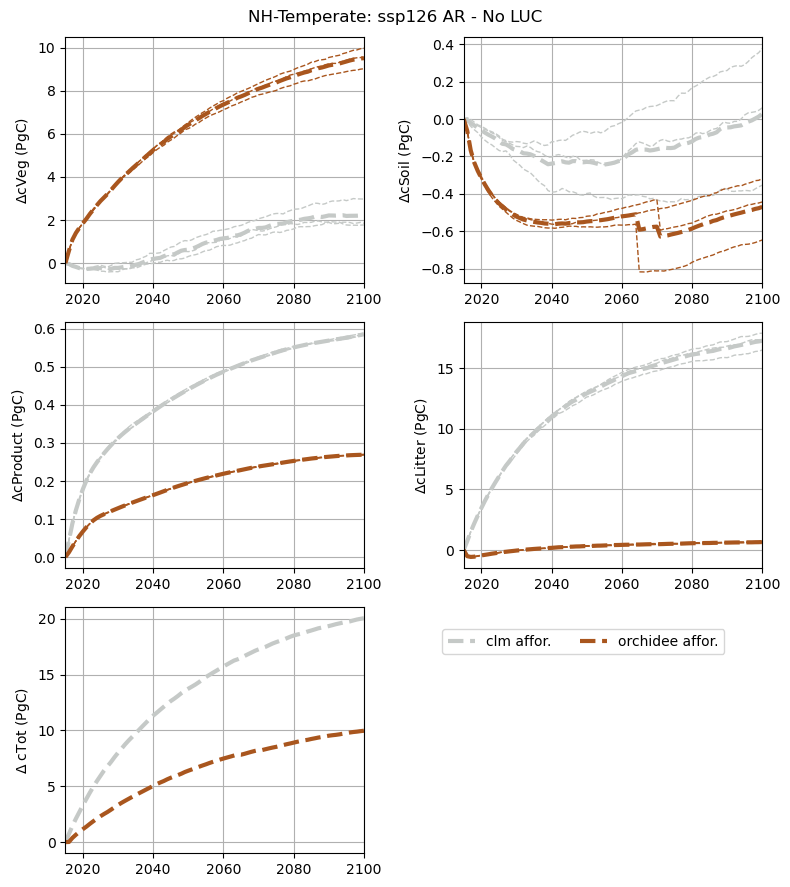

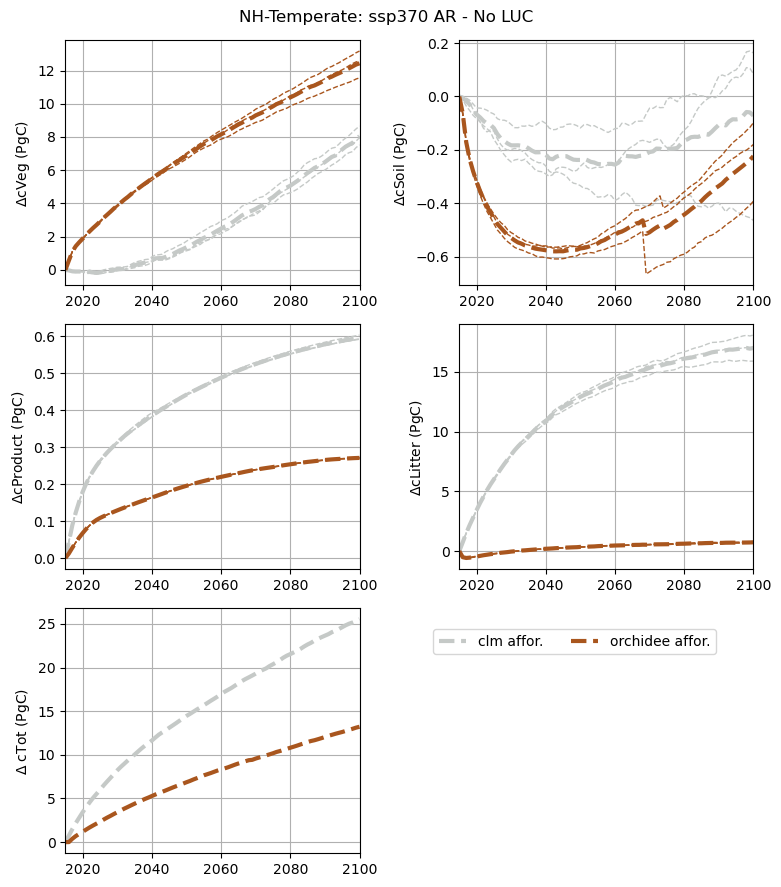

In [6]:
# PLOT NAT to AFFORESTATION

landuse_title=['nolucaff','noluc', \
               ' Agriculture to natural', \
               ' Agriculture to afforestation', ' Natural to afforestation']

#THIS DOES EXIST BUT THE MAPS SHOW THAT VEGETATION DECLINED IN ALL FORESTS WHICH IS NOT REALISTIC
landuse_exists['jules']['nattoaff']=False

ARTITLES=['reforestation','afforestation']
linestyles_AR = {title: [] for title in ARTITLES}
linestyles_AR['reforestation'] = '-'
linestyles_AR['afforestation'] = '--'

plotdiff = True
plot_all = True

ymin = (-5, -1, -0.4, -5, -5)
ymax = (30, 2, 1.2, 30, 50)
for region in REGIONS:
    i1=2
     
    for ssp in SSPS:

        #Set up plotting stuff
        #Each SSP scenario has a new figure
        fig2,axes2=plt.subplots(3,2, figsize=[8,9])
        if(plotdiff):
            fig2.suptitle(region+': '+ssp+' AR - No LUC',fontsize=12)
        else:
            fig2.suptitle(region+ssp,fontsize=12)
        i1+=1
        ix=0
        iy=0    

        ivar = 0

        for var in VARIABLES[:-1]:

            # set axes
            ax=axes2[iy,ix]
            ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
            ax.set_xlim([2015,2100])
            #ax.set_ylim([ymin[ivar],ymax[ivar]])
            ivar+=1
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules':
                    s0='nolucaff'
                else: 
                    s0='noluc'
 
                if (variable_exists[var][model]):
                    if (plotdiff):
                        if (landuse_exists[model]['nattoaff']): 
                            plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['nattoaff'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['nattoaff'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                    ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                        ls=linestyles_AR['afforestation'], lw=1)                        
                    else:
                        plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])[0])                        
                    if (landuse_exists[model]['nattoaff']):
                        ax.plot(years[:endyear], plot_luc_A, label=model+' affor.',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=3)
                        #print(var,model,ssp,plot_luc[-1])

                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)
            ix+=1
            if ix==2:
                ix=0
                iy+=1

        #Plot the sum
        ax=axes2[iy,ix]
        ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        for model in MODELS:
            if (landuse_exists[model]['nattoaff']):
                s0='noluc'

                ctot_luc_A=0
                ctot_luc_R=0
                ctot_noluc=0
                for var in VARIABLES[:-1]:

                    if (variable_exists[var][model]):
                        ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region][s0][ssp])
                        ctot_luc_A += np.array(LU_SCENARIO_MEAN[var][model][region]['nattoaff'][ssp])
                
                if plotdiff:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_luc_A[0])-(ctot_noluc-ctot_noluc[0]), 
                                     label=model+' affor.',
                                    c=colors[model],ls=linestyles_AR['afforestation'],lw=3)                        
                else:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_lucA[0]), 
                                label=model+' affor.',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=3)                        
                #print('cTot:',model,ssp,(ctot_luc_R-ctot_luc_R[0])[-1])
                del(ctot_noluc)
                del(ctot_luc_A)
                del(ctot_luc_R)


        handles2,labels2 = ax.get_legend_handles_labels()
        ax=axes2[2,1]
        ax.remove()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.55, 0.3),fontsize=10)
        fig2.tight_layout()
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_natAR-noluc_'+region+'_'+ssp+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_natAR_'+region+'_'+ssp+'.png', format="png")

calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff
calc total: jules nattoaff
calc total: clm nattoaff
calc total: jsbach nattoaff
calc total: orchidee nattoaff


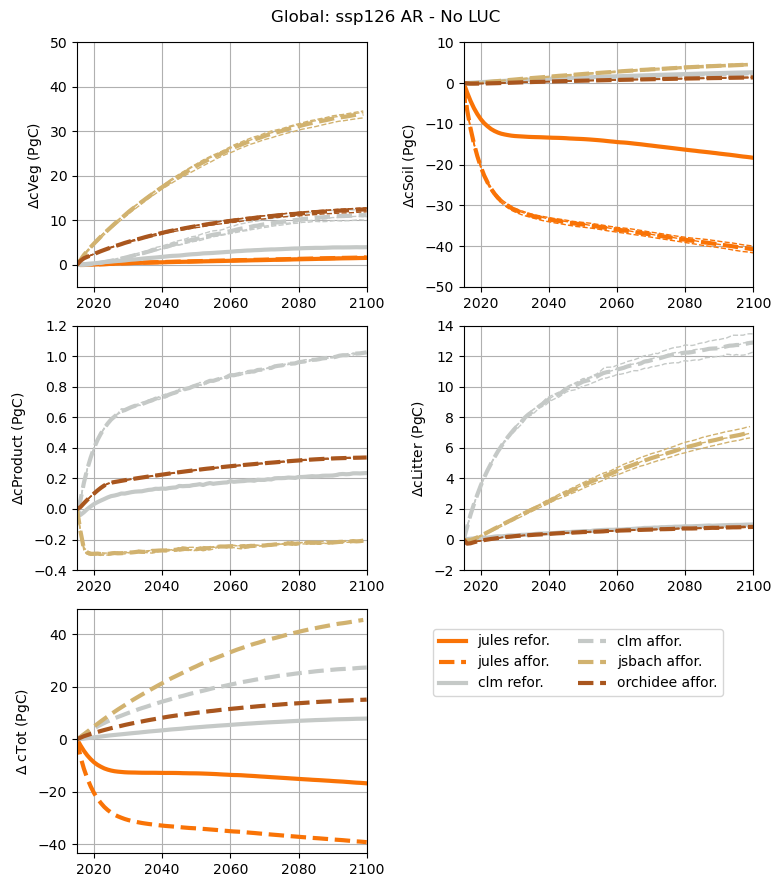

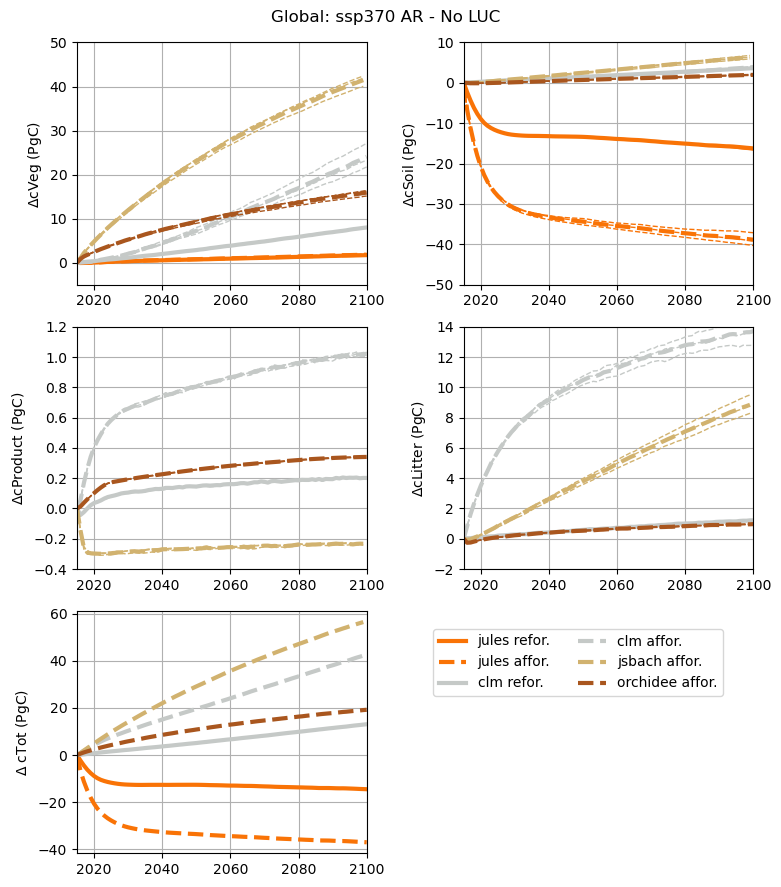

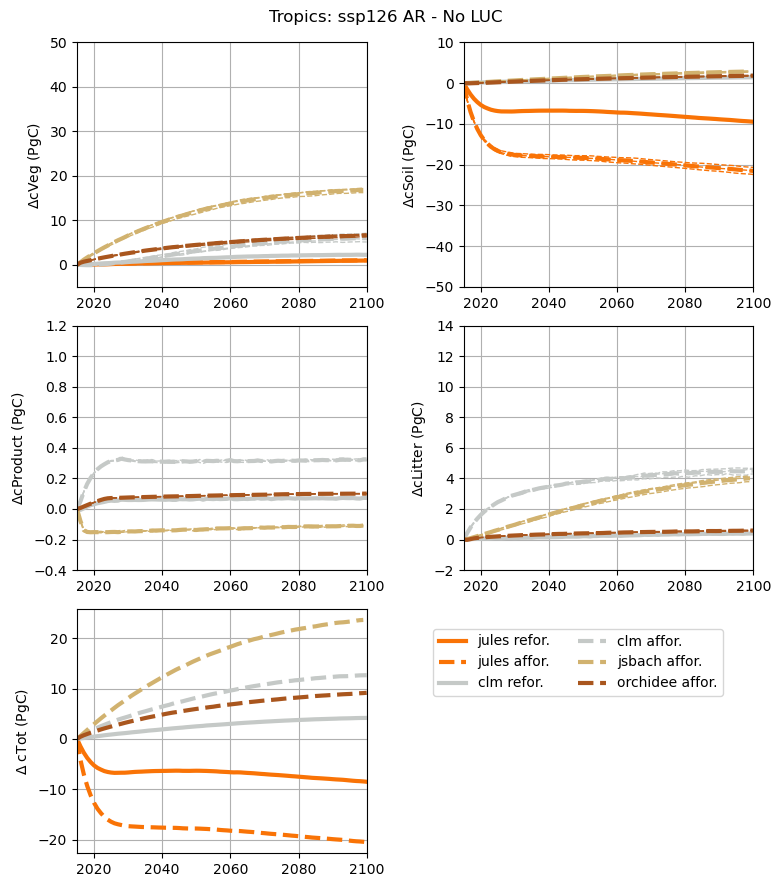

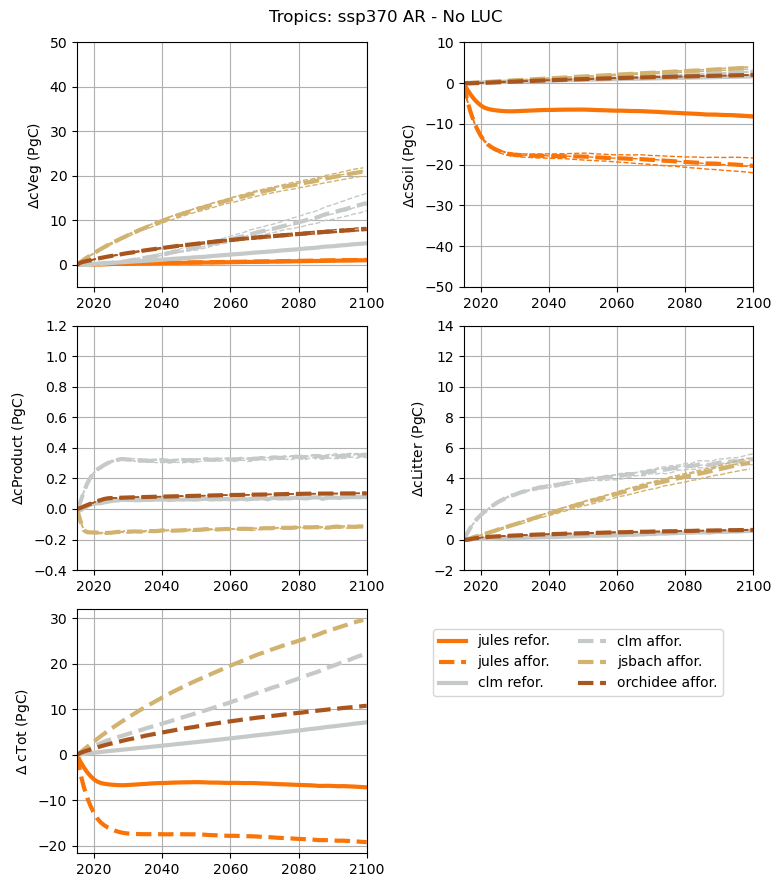

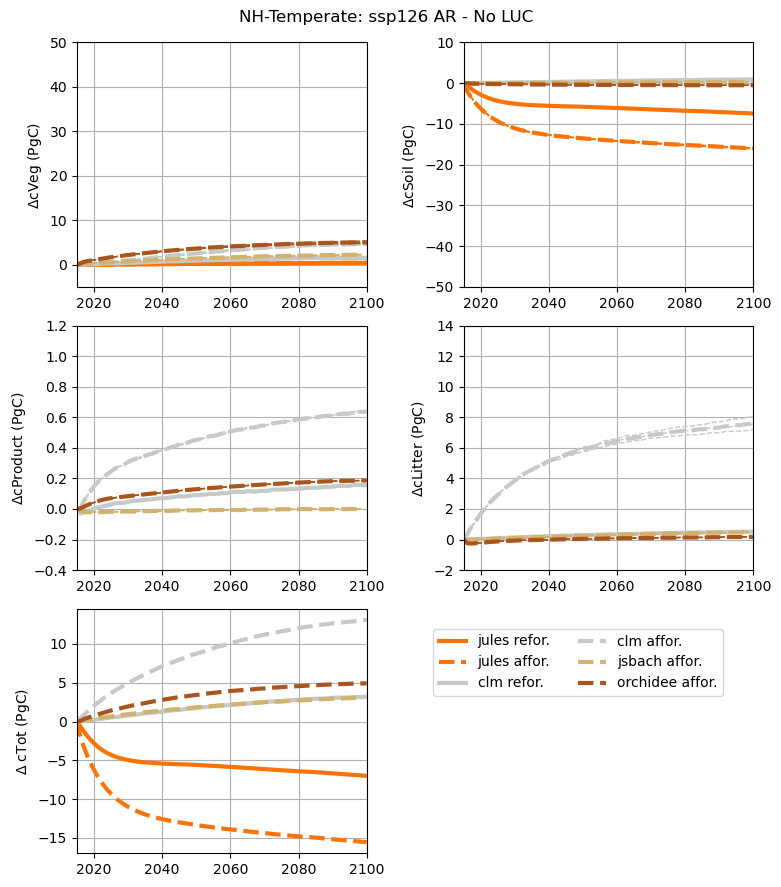

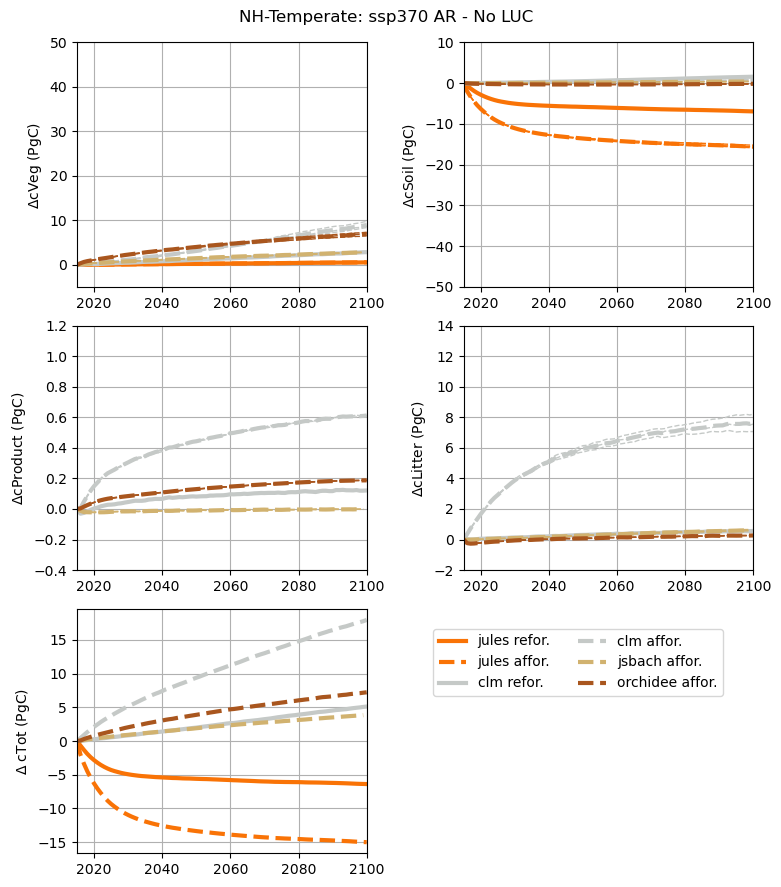

In [7]:
# PLOT BOTH AG to AFFORESTATION AND REFORESTATION ON THE SAME PLOT

landuse_title=['nolucaff','noluc', \
               ' Agriculture to natural', \
               ' Agriculture to afforestation', ' Natural to afforestation']

ARTITLES=['reforestation','afforestation']
linestyles_AR = {title: [] for title in ARTITLES}
linestyles_AR['reforestation'] = '-'
linestyles_AR['afforestation'] = '--'

plotdiff = True
plot_all = True

ymin = (-5, -50, -0.4, -2, -40)
ymax = (50, 10, 1.2, 14, 45)
for region in REGIONS:
    i1=2
     
    for ssp in SSPS:

        #Set up plotting stuff
        #Each SSP scenario has a new figure
        fig2,axes2=plt.subplots(3,2, figsize=[8,9])
        if(plotdiff):
            fig2.suptitle(region+': '+ssp+' AR - No LUC',fontsize=12)
        else:
            fig2.suptitle(region+ssp,fontsize=12)
        i1+=1
        ix=0
        iy=0    

        ivar = 0

        for var in VARIABLES[:-1]:

            # set axes
            ax=axes2[iy,ix]
            ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
            ax.set_xlim([2015,2100])
            ax.set_ylim([ymin[ivar],ymax[ivar]])
            ivar+=1
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules': 
                    s0='nolucaff'
                else: 
                    s0='noluc'
 
                if (variable_exists[var][model]):

                    if (plotdiff):
                        #print(var,model,region,ssp)
                        if (landuse_exists[model]['agtonat']): 
                            plot_luc_R=((LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['agtonat'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['agtonat'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                        ls=linestyles_AR['reforestation'], lw=1)
                        
                        if (landuse_exists[model]['agtoaff']): 
                            plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                        (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                            if plot_all:
                                for esm in ESMS:
                                    plot_clim=((LU_SCENARIO_ALL[var][model][region]['agtoaff'][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region]['agtoaff'][esm][ssp])[0]) - \
                                              ((LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])- \
                                              (LU_SCENARIO_ALL[var][model][region][s0][esm][ssp])[0])
                                    ax.plot(years[:endyear], plot_clim, c=colors[model], 
                                        ls=linestyles_AR['afforestation'], lw=1)                        
                    else:
                        plot_luc_R=((LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])[0])
                        plot_luc_A=((LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])- \
                                    (LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])[0])                        
                    if (landuse_exists[model]['agtonat']): 
                        ax.plot(years[:endyear], plot_luc_R, label=model+' refor.',
                                c=colors[model],ls=linestyles_AR['reforestation'],lw=3)
                    if (landuse_exists[model]['agtoaff']):
                        ax.plot(years[:endyear], plot_luc_A, label=model+' affor.',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=3)
                        #print(var,model,ssp,plot_luc[-1])

                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)
            ix+=1
            if ix==2:
                ix=0
                iy+=1

        #Plot the sum
        ax=axes2[iy,ix]
        ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        for model in MODELS:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears

            if model=='jules':
                s0='nolucaff'
            else: 
                s0='noluc'
            print('calc total:',model,landuse)
            ctot_luc_A=0
            ctot_luc_R=0
            ctot_noluc=0
            for var in VARIABLES[:-1]:

                if (variable_exists[var][model]):
                    ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region][s0][ssp])
                    if landuse_exists[model]['agtonat']:
                        ctot_luc_R += np.array(LU_SCENARIO_MEAN[var][model][region]['agtonat'][ssp])
                    if landuse_exists[model]['agtoaff']:
                        ctot_luc_A += np.array(LU_SCENARIO_MEAN[var][model][region]['agtoaff'][ssp])


            if plotdiff:
                if landuse_exists[model]['agtonat']:
                    ax.plot(years[:endyear], (ctot_luc_R-ctot_luc_R[0])-(ctot_noluc-ctot_noluc[0]), 
                                    label=model+' refor.',
                                    c=colors[model],ls=linestyles_AR['reforestation'],lw=3)
                if landuse_exists[model]['agtoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_luc_A[0])-(ctot_noluc-ctot_noluc[0]), 
                                     label=model+' affor.',
                                    c=colors[model],ls=linestyles_AR['afforestation'],lw=3)                        
            else:
                if landuse_exists[model]['agtonat']:
                    ax.plot(years[:endyear], (ctot_luc_R-ctot_luc_R[0]), 
                                label=model+' refor.',
                                c=colors[model],ls=linestyles_AR['reforestation'],lw=3)
                if landuse_exists[model]['agtoaff']:
                    ax.plot(years[:endyear], (ctot_luc_A-ctot_lucA[0]), 
                                label=model+' affor.',
                                c=colors[model],ls=linestyles_AR['afforestation'],lw=3)                        
            #print('cTot:',model,ssp,(ctot_luc_R-ctot_luc_R[0])[-1])
            del(ctot_noluc)
            del(ctot_luc_A)
            del(ctot_luc_R)


        handles2,labels2 = ax.get_legend_handles_labels()
        ax=axes2[2,1]
        ax.remove()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.55, 0.3),fontsize=10)
        fig2.tight_layout()
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_agAR-noluc_'+region+'_'+ssp+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_agAR_'+region+'_'+ssp+'.png', format="png")

In [20]:
# GET BOX-WHISKER CHART INFO FOR LAND USE SCENARIOS.
# For ESM2025 website summary:
# NOLUC = ORCHIDEE, CLM, JSBACH
# AgtoBio = JSBACH, CLM
# AgtoAff = JSBACH, CLM, ORCHIDEE

LANDUSES=['nolucaff','noluc','agtobio', 'agtonat', 'agtoaff', 'nattobio', 'nattoaff']
landuse_boxes = LANDUSES[1:]

use_landuse_boxplot = {lsm_mod: {landuse: [True] for landuse in LANDUSES} for lsm_mod in MODELS}
use_landuse_boxplot['jsbach']['agtonat'] = False
use_landuse_boxplot['jsbach']['nattoaff'] = False

#use_landuse_boxplot['orchidee']['noluc'] = False
use_landuse_boxplot['orchidee']['agtobio'] = False
use_landuse_boxplot['orchidee']['agtonat'] = False
use_landuse_boxplot['orchidee']['nattobio'] = False
use_landuse_boxplot['jules']['agtobio'] = False
use_landuse_boxplot['jules']['agtoaff'] = False
use_landuse_boxplot['jules']['nattobio'] = False
use_landuse_boxplot['jules']['nattoaff'] = False
use_landuse_boxplot['jules']['noluc'] = False

for model in MODELS:
    for ssp in SSPS:
        for landuse in landuse_boxes:
            for esm in ESMS:
                if landuse_exists[model][landuse]:
                    ctot=0
                    for var in VARIABLES[:-1]:
                        if variable_exists[var][model]:
                            #print(np.array(LU_SCENARIO_ALL[var][model]['Global'][landuse][esm][ssp]))                
                            ctot += np.array(LU_SCENARIO_ALL[var][model]['Global'][landuse][esm][ssp])
                    CTOT[landuse][model][ssp][esm]=ctot
                    del(ctot)
                else:
                    CTOT[landuse][model][ssp][esm]=np.empty((nyears))*np.nan


SSP126 2030s [1.8918017  3.62771822 3.95289792]
SSP126 2050s [1.30986027 2.65840164 3.2106193 ]
SSP126 2090s [0.29137622 0.74379308 0.89621106]


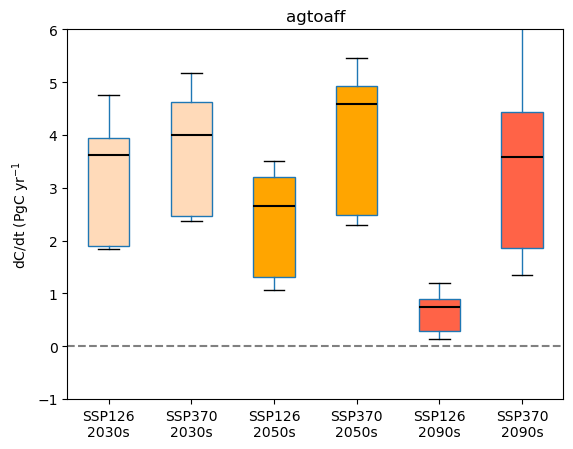

In [21]:
#BOXPLOT_INPUT = {decade: {landuse: {ssp_scen: [] for ssp_scen in SSPS} 
#                for landuse in LANDUSES} for decade in DECADES} 
#CTOT = {landuse: {lsm: {ssp: {esm: [] for esm in ESMS} for ssp in SSPS} 
#                  for lsm in MODELS} for landuse in LANDUSES}
import pandas as pd

colors = ['peachpuff', 'peachpuff','orange', 'orange','tomato','tomato']
#LANDUSES=['nolucaff','noluc','agtobio', 'agtonat','agtoaff', 'nattobio', 'nattoaff']


fig, ax = plt.subplots()
ax.set_ylabel('dC/dt (PgC yr$^{-1}$')

for landuse in landuse_boxes:
    for ssp in SSPS:
        i0=0
        for lsm in MODELS:
            if use_landuse_boxplot[lsm][landuse]:    
                for esm in ESMS:
                    BOXPLOT_INPUT['start'][landuse][ssp][i0] = np.mean(np.array(
                                            CTOT[landuse][lsm][ssp][esm][1:11]-\
                                            CTOT[landuse][lsm][ssp][esm][0:10]))
                    BOXPLOT_INPUT['2030s'][landuse][ssp][i0] = np.mean(np.array(
                                            CTOT[landuse][lsm][ssp][esm][15:25]-\
                                            CTOT[landuse][lsm][ssp][esm][14:24]))
                    BOXPLOT_INPUT['2050s'][landuse][ssp][i0] = np.mean(np.array(
                                            CTOT[landuse][lsm][ssp][esm][35:45]-\
                                            CTOT[landuse][lsm][ssp][esm][34:44]))
                    BOXPLOT_INPUT['2090s'][landuse][ssp][i0] = np.mean(np.array(
                                            CTOT[landuse][lsm][ssp][esm][75:85]-\
                                            CTOT[landuse][lsm][ssp][esm][74:84]))                
                    i0+=1
            else:
                for esm in ESMS:
                    BOXPLOT_INPUT['start'][landuse][ssp][i0] = np.nan
                    BOXPLOT_INPUT['2030s'][landuse][ssp][i0] = np.nan
                    BOXPLOT_INPUT['2050s'][landuse][ssp][i0] = np.nan
                    BOXPLOT_INPUT['2090s'][landuse][ssp][i0] = np.nan                    
                    i0+=1
            #print(BOXPLOT_INPUT['2030s'][landuse][ssp])


scenario_to_plot='agtoaff'

plot_array = [list(BOXPLOT_INPUT['2030s'][scenario_to_plot]['ssp126'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot]['ssp370'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot]['ssp126'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot]['ssp370'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp126'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp370'].values())]

dummy_var=list(BOXPLOT_INPUT['start'][scenario_to_plot]['ssp126'].values())
#filtered_data = dummy_var[~np.isnan(dummy_var)]
#print(dummy_var)
#print("SSP126 2016-2025",np.percentile(filtered_data,\
#                                   (25,50,75)))
#print("SSP126 2016-2025",np.nanpercentile(list(BOXPLOT_INPUT['start'][scenario_to_plot]['ssp126'].values()),\
#                                   (25,50,75)))
print("SSP126 2030s",np.nanpercentile(list(BOXPLOT_INPUT['2030s'][scenario_to_plot]['ssp126'].values()),\
                                   (25,50,75)))
print("SSP126 2050s",np.nanpercentile(list(BOXPLOT_INPUT['2050s'][scenario_to_plot]['ssp126'].values()),\
                                   (25,50,75)))
print("SSP126 2090s",np.nanpercentile(list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp126'].values()),\
                                   (25,50,75)))
#print("SSP370 2016-2025",np.nanpercentile(list(BOXPLOT_INPUT['start'][scenario_to_plot]['ssp370'].values()),\
#                                   (25,50,75)))
#print("SSP370 2030s",np.nanpercentile(list(BOXPLOT_INPUT['2030s'][scenario_to_plot]['ssp370'].values()),\
#                                   (25,50,75)))
#print("SSP370 2050s",np.nanpercentile(list(BOXPLOT_INPUT['2050s'][scenario_to_plot]['ssp370'].values()),\
#                                   (25,50,75)))
#print("SSP370 2090s",np.nanpercentile(list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp370'].values()),\
#                                   (25,50,75)))
#print(np.min(list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp370'].values())),np.max(list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp370'].values())))
#print(list(BOXPLOT_INPUT['2090s'][scenario_to_plot]['ssp126'].values()))
dframe = pd.DataFrame(plot_array)
dframeT = dframe.transpose()
dframeT.columns = [r"SSP126" "\n" r"2030s",
        r"SSP370" "\n" r"2030s",
        r"SSP126" "\n" r"2050s",
        r"SSP370" "\n" r"2050s",
        r"SSP126" "\n" r"2090s",
        r"SSP370" "\n" r"2090s"]
ax, bplot = dframeT.boxplot(grid=False, medianprops=dict(color='black', linewidth=1.5), 
                   patch_artist=True, return_type="both", ax=ax)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

#bplot = ax.boxplot(plot_array[dmask], medianprops=dict(color='black', linewidth=1.5), 
#                   patch_artist=True, labels=labels)  # will be used to label x-ticks
ax.axhline(y=0, color='gray', linestyle='--')
ax.set_title(scenario_to_plot)
ax.set_ylim(-1,6)

# fill with colors
#for patch, color in zip(bplot['boxes'], colors):
#    patch.set_facecolor(color)
plt.savefig('/bdd/ESM2025/WP10/plots/dCdt_Global_'+scenario_to_plot+'.png', format="png", dpi=400)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


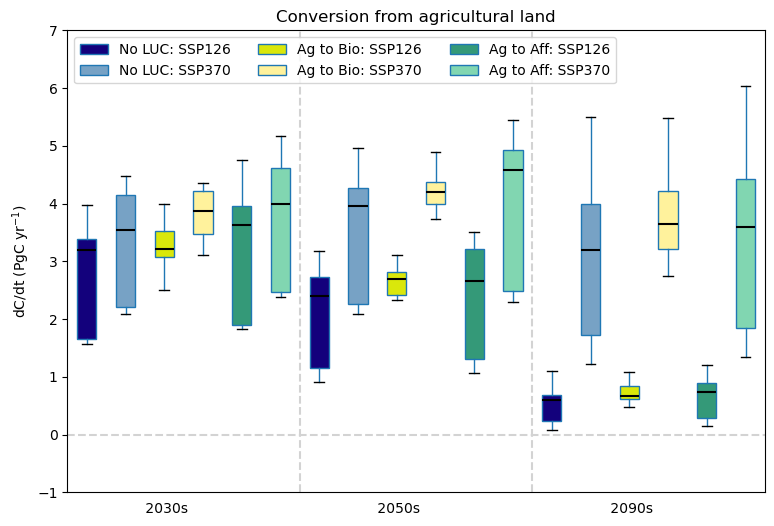

In [22]:
scenario_to_plot1='noluc'
scenario_to_plot2='agtobio'
scenario_to_plot3='agtoaff'

fig2, ax2 = plt.subplots(figsize=[9,6])
ax2.set_ylabel('dC/dt (PgC yr$^{-1}$)')
#https://latexcolor.com/
labels=[" ",r"SSP126" "\n" r"2030s", " ",
        " ",r"SSP370" "\n" r"2030s"," ",
        " ",r"SSP126" "\n" r"2050s"," ",
        " ",r"SSP370" "\n" r"2050s"," ",
        " ",r"SSP126" "\n" r"2090s"," ",
        " ",r"SSP370" "\n" r"2090s"," "]
colors = ['#13017C', '#77A2C5', '#DAE70B',
         '#FFF29C', '#349978', '#81D6B1',
         '#13017C', '#77A2C5', '#DAE70B',
         '#FFF29C', '#349978', '#81D6B1',
         '#13017C', '#77A2C5', '#DAE70B',
         '#FFF29C', '#349978', '#81D6B1']

plot_array = [list(BOXPLOT_INPUT['2030s'][scenario_to_plot1]['ssp126'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot1]['ssp370'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot2]['ssp126'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot2]['ssp370'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot3]['ssp126'].values()),
              list(BOXPLOT_INPUT['2030s'][scenario_to_plot3]['ssp370'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot1]['ssp126'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot1]['ssp370'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot2]['ssp126'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot2]['ssp370'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot3]['ssp126'].values()),
              list(BOXPLOT_INPUT['2050s'][scenario_to_plot3]['ssp370'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot1]['ssp126'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot1]['ssp370'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot2]['ssp126'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot2]['ssp370'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot3]['ssp126'].values()),
              list(BOXPLOT_INPUT['2090s'][scenario_to_plot3]['ssp370'].values())]


dframe = pd.DataFrame(plot_array)
dframeT = dframe.transpose()
dframeT.columns = [" "," "," 2030s"," "," "," ",
                   " "," "," 2050s"," "," "," ",
                   " "," "," 2090s"," "," "," "]

ax2, bplot = dframeT.boxplot(grid=False, showfliers=False, 
                             medianprops=dict(color='black', linewidth=1.5), 
                             patch_artist=True, return_type="both", ax=ax2)

for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    
ax2.axhline(y=0, color='lightgray', linestyle='--')
ax2.axvline(x=6.5, color='lightgray', linestyle='--')
ax2.axvline(x=12.5, color='lightgray', linestyle='--')

ax2.set_title('Conversion from agricultural land')
ax2.set_ylim(-1,7)
ax2.xaxis.set_ticks_position('none') 

ax2.legend([bplot["boxes"][0], bplot["boxes"][1], bplot["boxes"][2],
            bplot["boxes"][3], bplot["boxes"][4], bplot["boxes"][5]], 
           ['No LUC: SSP126', 'No LUC: SSP370', 'Ag to Bio: SSP126',
           'Ag to Bio: SSP370', 'Ag to Aff: SSP126', 'Ag to Aff: SSP370'], 
           loc='upper left', ncol=3)

#plt.savefig('/bdd/ESM2025/WP10/plots/dCdt_Global_multi_fromag.png', format="png", dpi=400)
plt.savefig('/bdd/ESM2025/WP10/plots/dCdt_Global_multi_fromag.eps', format="eps", dpi=1200)

In [ ]:
# PLOT THE LANDUSE SCENARIO DIFFERENCE FROM THE NOLUC SCENARIO

landuse_title=['nolucaff','noluc',' Agriculture to bioenergy', ' Natural to bioenergy', \
               ' Agriculture to natural', \
               ' Agriculture to afforestation', ' Natural to afforestation']

plotdiff = True
plot_all = False

for region in REGIONS:
    i1=2
    for landuse in LANDUSES[2:]:
     
        #Set up plotting stuff
        #Each land use scenario has a new figure
        fig2,axes2=plt.subplots(3,2, figsize=[8,9])
        if(plotdiff):
            fig2.suptitle(region+landuse_title[i1]+'- No LUC',fontsize=12)
        else:
            fig2.suptitle(region+landuse_title[i1],fontsize=12)
        i1+=1
        ix=0
        iy=0    

        for var in VARIABLES[:-1]:

            # set axes
            ax=axes2[iy,ix]
            ax.set_ylabel(r'$\Delta$' +var+' (PgC) ',fontsize=10)
            ax.set_xlim([2015,2100])
            ax.grid(True) 
        
            for model in MODELS:
                if model=='jsbach':
                    endyear=nyears-1
                else:
                    endyear=nyears
                if model=='jules' and (landuse=='agtonat' or landuse=='agtoaff' or landuse=='nattoaff'):
                    s0='nolucaff'
                else: 
                    s0='noluc'

                
                if (landuse_exists[model][landuse] and variable_exists[var][model]):

                    for ssp in SSPS:

                        if (plotdiff):
                            plot_luc=((LU_SCENARIO_MEAN[var][model][region][landuse][ssp])- \
                                       (LU_SCENARIO_MEAN[var][model][region][landuse][ssp])[0])- \
                                        ((LU_SCENARIO_MEAN[var][model][region][s0][ssp])- \
                                       (LU_SCENARIO_MEAN[var][model][region][s0][ssp])[0])
                        else:
                            plot_luc=((LU_SCENARIO_MEAN[var][model][region][landuse][ssp])- \
                                       (LU_SCENARIO_MEAN[var][model][region][landuse][ssp])[0])
                        ax.plot(years[:endyear], plot_luc, label=model+' '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=3)

                        #print(var,model,ssp,plot_luc[-1])

                        #m,b = np.polyfit(years[endyear-20:endyear-1],plot_noluc[-20:-1], 1)
                        #print(var,model,ssp,'slope over last 20 years:',m)
            ix+=1
            if ix==2:
                ix=0
                iy+=1

        #Plot the sum
        ax=axes2[iy,ix]
        ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
        ax.set_xlim([2015,2100])
        ax.grid(True) 
        for model in MODELS:
            if (landuse_exists[model][landuse]):
                for ssp in SSPS:
                    if model=='jsbach':
                        endyear=nyears-1
                    else:
                        endyear=nyears

                    if model=='jules' and (landuse=='agtonat' or landuse=='agtoaff' or landuse=='nattoaff'):
                        s0='nolucaff'
                    else: 
                        s0='noluc'

                    ctot_luc=0
                    ctot_noluc=0
                    for var in VARIABLES[:-1]:

                        if (variable_exists[var][model]):
                            ctot_noluc += np.array(LU_SCENARIO_MEAN[var][model][region][s0][ssp])
                            ctot_luc += np.array(LU_SCENARIO_MEAN[var][model][region][landuse][ssp])


                    if plotdiff:
                        ax.plot(years[:endyear], (ctot_luc-ctot_luc[0])-(ctot_noluc-ctot_noluc[0]), 
                                label=model+' '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=3)
                    else:
                        ax.plot(years[:endyear], (ctot_luc-ctot_luc[0]), 
                                label=model+' '+ssp,
                                c=colors[model],ls=linestyles[ssp],lw=3)
                    print('cTot:',model,ssp,(ctot_luc-ctot_luc[0])[-1])
                    del(ctot_noluc)
                    del(ctot_luc)


        handles2,labels2 = ax.get_legend_handles_labels()
        ax=axes2[2,1]
        ax.remove()
        fig2.legend(handles2,labels2,ncol=2,loc='upper left',bbox_to_anchor=(0.55, 0.3),fontsize=10)
        fig2.tight_layout()
        if plotdiff:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_'+landuse+'-noluc_'+region+'.png', format="png")
        else:
            plt.savefig('/bdd/ESM2025/WP10/plots/cpools_'+landuse+'_'+region+'.png', format="png")

In [ ]:
def plot_noluc_scenario(OUTPUT_DICT,region)


    #Set up plotting stuff
    #Each land model needs a different color
    fig,axes=plt.subplots(3,2, figsize=[12,8])
    fig.suptitle('Global: No land use change',fontsize=12)
    ix=0
    iy=0
    
    colors = {model: [] for model in MODELS}
    colors['jules'] = '#F97306'
    colors['clm'] = '#C5C9C7'
    colors['jsbach'] = '#D1B26F'
    colors['orchidee'] = '#A9561E'
    #https://matplotlib.org/stable/users/explain/colors/colors.html
    
    #Plot the sum
    ax=axes[iy,ix]
    ax.set_ylabel(r'$\Delta$ cTot (PgC) ',fontsize=10)
    ax.set_xlim([2015,2100])
    ax.grid(True) 
    for model in MODELS:
        for ssp in SSPS:
            if model=='jsbach':
                endyear=nyears-1
            else:
                endyear=nyears
            ctot_noluc=0
            for var in VARIABLES[:-1]:
                if variable_exists[var][model]:
                    ctot_noluc += np.array(OUTPUT_DICT[var][model][region]['noluc'][ssp])
        
            ax.plot(years[:endyear], (ctot_noluc-ctot_noluc[0]), label=model+' '+ssp,
                    c=colors[model],ls=linestyles[ssp],lw=3)
            #print('cTot:',model,ssp,(ctot_noluc-ctot_noluc[0])[-1])
            del(ctot_noluc)


    handles,labels = ax.get_legend_handles_labels()
    ax=axes[2,1]
    ax.remove()
    fig.legend(handles,labels,ncol=2,loc='upper left',bbox_to_anchor=(0.55, 0.3),fontsize=10)

    plt.savefig('/bdd/ESM2025/WP10/plots/cpools_noluc_'+region+'.png', format="png")